In [1]:
%load_ext autoreload
%autoreload 2

https://www.10xgenomics.com/analysis-guides/segmentation-visium-hd

In [2]:
import os
import sparrow as sp
import spatialdata as sd

/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
2025-06-17 13:50:40,558 - sparrow.image.pixel_clustering._clustering - WARNING - 'flowsom' not installed, to use 'sp.im.flowsom', please install this library.
2025-06-17 13:50:41,559 - sparrow.table.cell_clustering._clustering - WARNING - 'flowsom' not installed, to use 'sp.tb.flowsom', please install this library.
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/ann

In [3]:
#path = "/Users/arnedf/VIB/DATA/visium" # pick a path where the zarr store will be saved
#sdata=sp.datasets.visium_hd_example( bin_size=[ 2, 8, 16 ], output = os.path.join( path, "sdata_custom_binning_example.zarr" ) )
sdata = sd.read_zarr("/home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_zarr")


In [4]:
import json

json_file = "/run/media/chananchidas/T7 Touch/visium-hd_17062025/data/Visium_HD_Liver/binned_outputs/square_016um/spatial/scalefactors_json.json"

# Load the JSON file
with open(json_file, 'r') as f:
    scalefactors = json.load(f)

# Print the loaded JSON data
print(scalefactors)
spot_diameter_32um = scalefactors['spot_diameter_fullres'] * 2


{'spot_diameter_fullres': 72.6960582873374, 'bin_size_um': 16.0, 'microns_per_pixel': 0.22009446422471257, 'regist_target_img_scalef': 0.121971056, 'tissue_lowres_scalef': 0.012197105, 'fiducial_diameter_fullres': 1499.3562021763337, 'tissue_hires_scalef': 0.121971056}


create a grid

In [5]:
sdata

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_zarr
├── Images
│     ├── 'Visium_HD_Liver_full_image': DataTree[cyx] (3, 32447, 49192), (3, 16223, 24596), (3, 8111, 12298), (3, 4055, 6149), (3, 2027, 3074)
│     ├── 'Visium_HD_Liver_hires_image': DataArray[cyx] (3, 3958, 6000)
│     └── 'Visium_HD_Liver_lowres_image': DataArray[cyx] (3, 396, 600)
├── Labels
│     ├── 'Visium_HD_Liver_square_002um_labels': DataArray[yx] (3347, 3350)
│     ├── 'Visium_HD_Liver_square_008um_labels': DataArray[yx] (837, 838)
│     ├── 'Visium_HD_Liver_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'segmentation_mask': DataArray[yx] (32447, 49192)
├── Shapes
│     ├── 'Visium_HD_Liver_square_002um': GeoDataFrame shape: (7375079, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_008um': GeoDataFrame shape: (462269, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_016um': GeoDataFrame shape: (115975, 1) (2D shapes)
│     └── 'segmenta

In [6]:
# take shape of grid equal to full h&e image
se = sdata["Visium_HD_Liver_full_image"]["scale0"]["image"]
sdata = sp.im.add_grid_labels_layer(sdata, shape = se.shape[1:], size=spot_diameter_32um, output_shapes_layer="Visium_HD_Liver_square_032um",
                                    output_labels_layer="Visium_HD_Liver_square_032um_labels", grid_type="square", overwrite=True,
                                    chunks=256)

: 

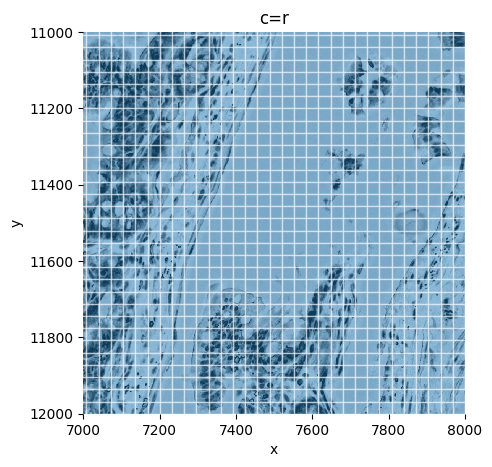

In [ ]:
# lets plot the grid
sp.pl.plot_shapes( sdata,
                  img_layer="CAW009_full_image",
                  shapes_layer="square_shapes", 
                  crd = [7000,8000,11000, 12000],
                  channel = "r",
                  figsize=(5,5)
                   )

In [ ]:
# now do a custom binning using the generated labels layer 'square_labels'.
# below step should be quite fast, 50-ish seconds on mac m2
sdata=sp.tb.bin_counts( 
    sdata,
    table_layer="square_002um",
    labels_layer="square_labels",
    output_layer="table_custom_bins",
    append = False,
    overwrite=True,
      )

2024-10-09 13:44:14,678 - sparrow.table._allocation - INFO - Calculating cell counts.
2024-10-09 13:44:38,769 - sparrow.table._allocation - INFO - 
 Number of spots per bin  Frequency
                       1        675
                       2       1284
                       3        728
                       4       1933
                       5        692
                       6        946
                       7        213
                       8       1795
                       9        340
                      10       1192
                      11        331
                      12       1838
                      13        469
                      14        990
                      15        936
                      16     100368
                      17       4915
                      18       5051
                      19       4955
                      20     118720
                      21       2896
                      22       2758
                      23

2024-10-09 13:45:09,846 - sparrow.plot._plot - WARNING - There are '285' cells in provided shapes_layer 'square_shapes' not found in 'sdata.tables[table_custom_bins]' (linked through 'cell_ID'), these cells will not be plotted.


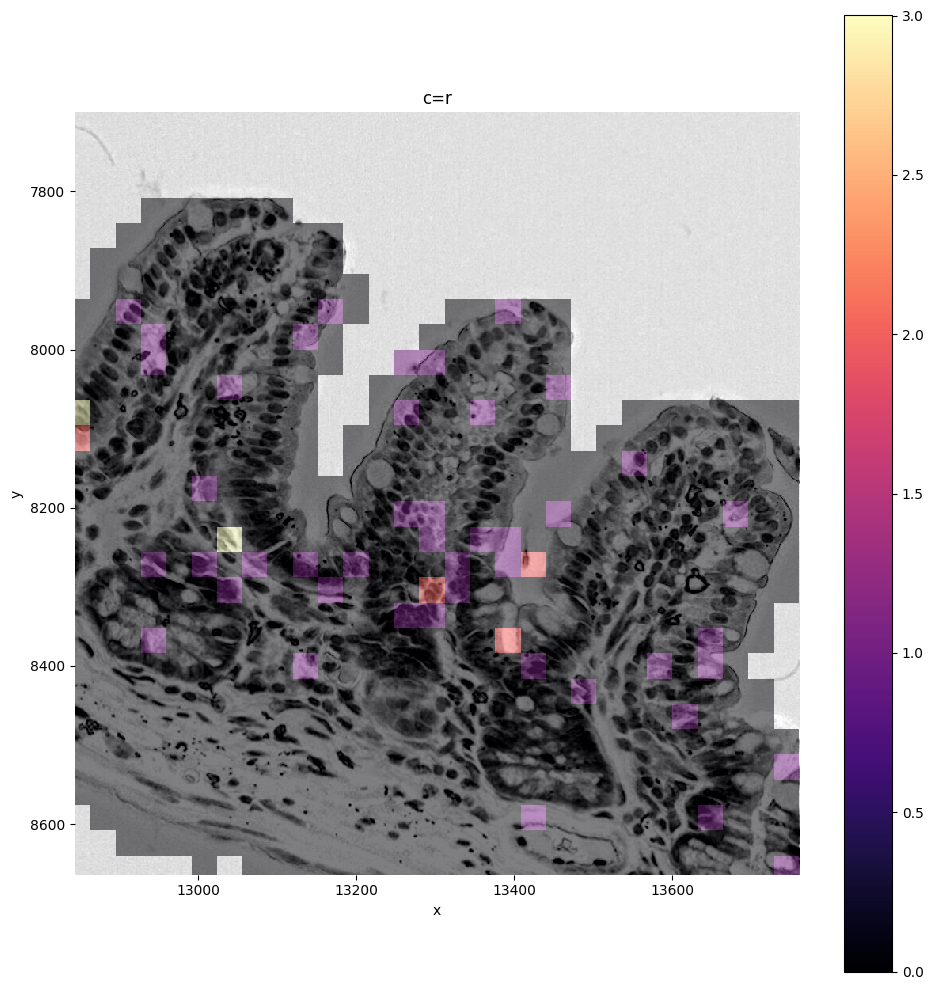

In [ ]:
sp.pl.plot_shapes(
    sdata,
    img_layer = "Visium_HD_Mouse_Small_Intestine_full_image",
    shapes_layer="square_shapes",
    crd = [ 12844, 13760, 7700, 8664 ],
    channel="r",
    table_layer = "table_custom_bins",
    column="Lypla1",
    linewidth=0,
      )

2024-10-09 13:45:24,636 - sparrow.plot._plot - WARNING - There are '9421' cells in provided shapes_layer 'square_shapes' not found in 'sdata.tables[table_custom_bins]' (linked through 'cell_ID'), these cells will not be plotted.


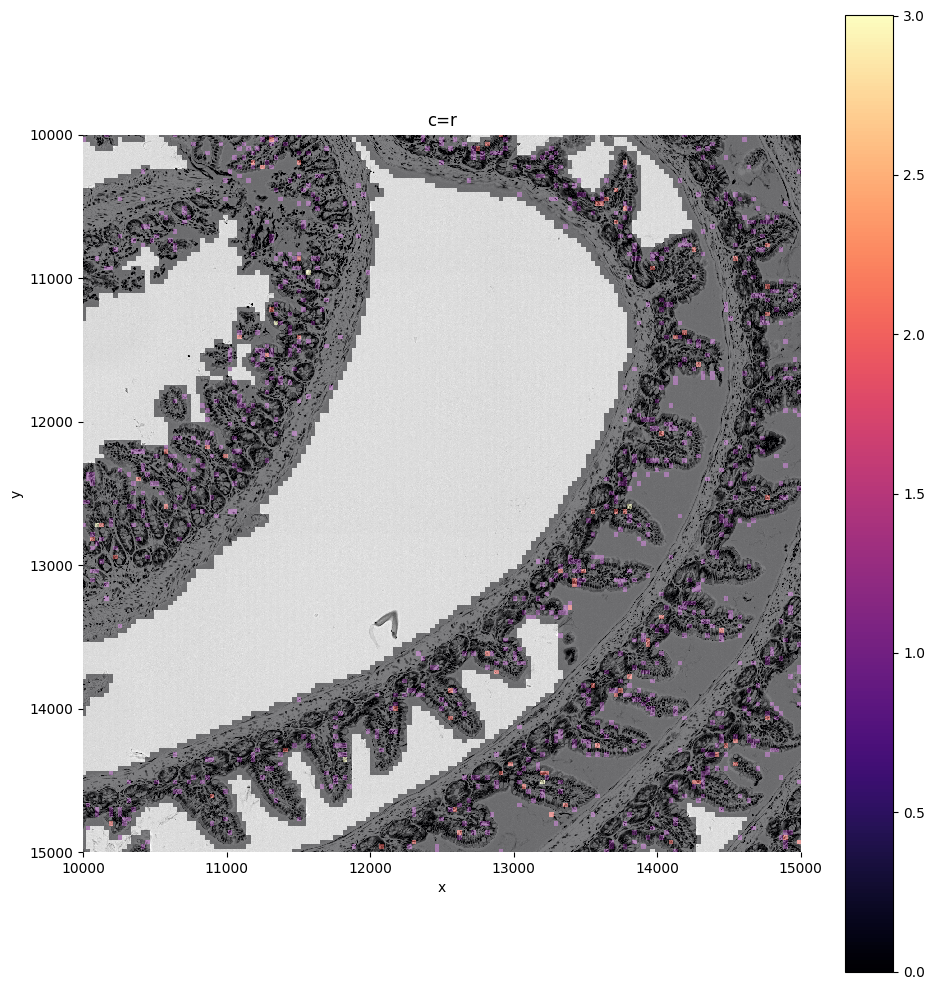

In [ ]:
sp.pl.plot_shapes(
    sdata,
    img_layer = "Visium_HD_Mouse_Small_Intestine_full_image",
    shapes_layer="square_shapes", # shapes layer associated with our custom bin
    crd = [10000, 15000, 10000, 15000 ],
    channel="r",
    table_layer = "table_custom_bins",
    column="Lypla1",
    linewidth=0,
      )

In [30]:
import scanpy as sc

# you can then proceed doing normalization, and other processing steps using scanpy/squidpy etc...
adata_norm=sc.pp.normalize_total( sdata.tables[ "table_custom_bins" ] )

In [31]:
#import numpy as np

#np.where(sdata.tables[ "table_custom_bins" ].X[0].toarray() !=0 )

(array([0, 0, 0]), array([ 7337, 13546, 13963]))

In [32]:
#sdata.tables[ "table_custom_bins" ].X[0].toarray()[ :, 7337 ]

array([127.])

Now lets use a custom segmentation mask instead of a grid

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument '

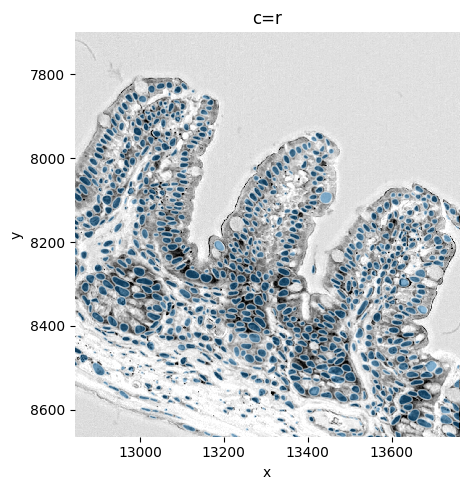

In [ ]:
import geopandas as gpd

from sparrow.datasets.registry import get_registry

registry = get_registry()

# read in a mask, and add it to the spatialdata object ( obtained from visium hd tutorial)
# https://www.10xgenomics.com/analysis-guides/segmentation-visium-hd

path_polygons = registry.fetch( "transcriptomics/visium_hd/mouse/masks.geojson" ) # custom segmentation of H&E

gdf = gpd.read_file(path_polygons)
gdf.index=gdf.index +1

sdata=sp.sh.add_shapes_layer(
    sdata,
    input=gdf,
    output_layer="segmentation_boundaries",
    overwrite=True,
      )

sp.pl.plot_shapes(
    sdata, 
    img_layer="Visium_HD_Mouse_Small_Intestine_full_image",
    shapes_layer="segmentation_boundaries",
    crd =[ 12844, 13760, 7700, 8664 ],
    figsize=(5,5) ,
    channel="r",
      )

In [5]:
labels_layer = "segmentation_mask"
sdata=sp.im.rasterize( sdata, shapes_layer="segmentation_boundaries", output_layer=labels_layer, overwrite=True )

2024-10-09 16:32:42,077 - sparrow.image._manager - WARNING - No dims parameter specified. Assuming order of dimension of provided array is ((c), (z), y, x)
2024-10-09 16:32:42,082 - sparrow.image._manager - INFO - Writing results to layer 'segmentation_mask'
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614

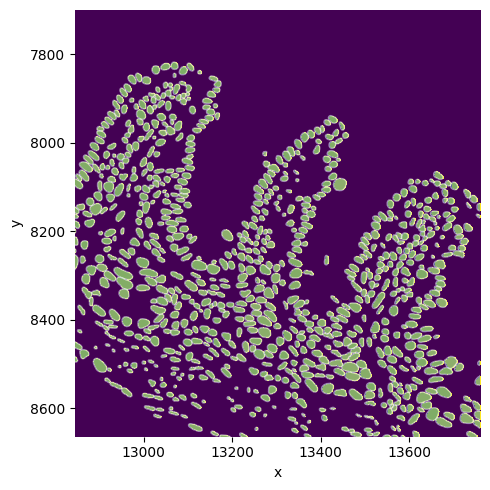

In [6]:
# sanity plot
sp.pl.plot_shapes(
    sdata, 
    labels_layer="segmentation_mask",
    shapes_layer="segmentation_boundaries",
    crd =[ 12844, 13760, 7700, 8664 ],
    figsize=(5,5),
    channel="r",
      )

In [8]:
# bin barcodes to the segmentation masks
sdata=sp.tb.bin_counts( 
    sdata,
    table_layer="square_002um",
    labels_layer="segmentation_mask",
    output_layer="table_custom_segmentation",
    append = False,
    overwrite=True,
      )

2024-10-09 16:34:30,115 - sparrow.table._allocation - INFO - Calculating cell counts.
2024-10-09 16:34:34,467 - sparrow.table._allocation - INFO - 
 Number of spots per bin  Frequency
                       1      59852
                       2      86037
                       3      71787
                       4      59368
                       5      32236
                       6      19129
                       7      11249
                       8       6894
                       9       4362
                      10       3060
                      11       1947
                      12       1427
                      13        942
                      14        699
                      15        409
                      16        294
                      17        211
                      18        139
                      19         94
                      20         57
                      21         58
                      22         35
                      23

2024-10-09 16:34:48,952 - sparrow.plot._plot - WARNING - There are '15' cells in provided shapes_layer 'segmentation_boundaries' not found in 'sdata.tables[table_custom_segmentation]' (linked through 'cell_ID'), these cells will not be plotted.


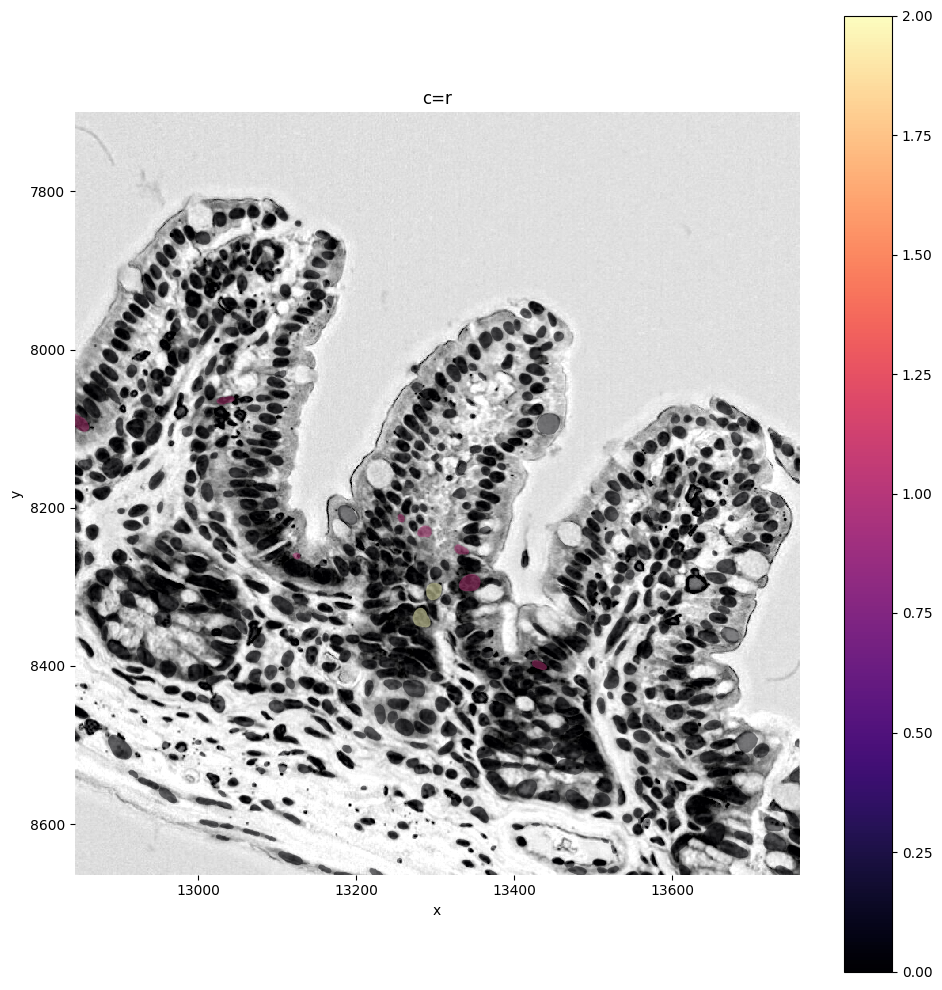

In [9]:
sp.pl.plot_shapes(
    sdata,
    img_layer = "Visium_HD_Mouse_Small_Intestine_full_image",
    shapes_layer="segmentation_boundaries", # shapes layer corresponding to labels layer
    crd = [ 12844, 13760, 7700, 8664 ],
    channel="r",
    table_layer = "table_custom_segmentation",
    column="Lypla1",
    linewidth=0,
      )